# Experiment 1: Chunking

In this first experiment, we compare  two different approaches for splitting documents into chunks: 
- **Naive Chunking**: Text is split into fixed-size chunks of 400 characters, without considering sentence or semantic boundaries.
- **LLM-based chunking**: An LLM is used to determine meaningful chunk boundaries, aiming to preserve semantic coherence within each chunk. 


The code that calls the LLM and does the chunking is *llm_chunker.py*, that creates the *llm_database.json* that we use in this jupyter notebook.

## Part 1: Initializations

In [ ]:
import os
import json
import time
import requests
from pathlib import Path
import fitz # pip install PyMuPDF
import numpy as np
from collections import defaultdict

from embedder import Embedder

In [ ]:
DATA_DIR = Path("data")
PDF_DIR = Path("pdfs")

DATA_DIR.mkdir(exist_ok=True)

api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    raise RuntimeError("Missing GEMINI_API_KEY environment variable")

In [3]:
def extract_text_from_pdf(pdf_path: Path) -> str:
    doc = fitz.open(pdf_path)
    text = "".join(page.get_text() for page in doc)
    doc.close()
    return text

In [ ]:


BASE_DIR = Path.cwd()#.parents[0]   # backend/
PDF_EXAMPLES = BASE_DIR/ "example_pdfs_to_upload"

DATA_DIR = BASE_DIR / "data"
META_CACHE_PATH = DATA_DIR / "llm_metadata_cache.json"


'if not META_CACHE_PATH.exists():\n    raise RuntimeError("llm_metadata_cache.json not found. Metadata must be precomputed.")\n\nwith META_CACHE_PATH.open("r", encoding="utf-8") as f:\n    metadata_cache = json.load(f)'

## PART 2: Create embeddings and retrievers

In [ ]:


class DataManager:
    """
    Handles:
    - PDF text extraction
    - Chunking
    - Embedding (baseline / concat / dual)
    """

    def __init__(self, pdf_folder, metadata_mode="concat"):
        self.embedder = Embedder()
        self.pdf_folder = pdf_folder
        self.metadata_mode = metadata_mode
        self.tokenizer = self.embedder.model.tokenizer

    # ------------------------------
    # PDF TEXT EXTRACTION
    # ------------------------------
    def extract_text(self, pdf_path):
        doc = fitz.open(pdf_path)
        text = "".join(page.get_text() for page in doc)
        doc.close()
        return text

    # ------------------------------
    # CHUNKING
    # ------------------------------
    def chunk_text(self, text, chunk_size=400, chunk_overlap=50):
        tokens = self.tokenizer.encode(text, add_special_tokens=False)

        chunks = []
        step = chunk_size - chunk_overlap

        for i in range(0, len(tokens), step):
            chunk_ids = tokens[i:i + chunk_size]
            chunk_text = self.tokenizer.decode(chunk_ids, skip_special_tokens=True)
            chunks.append(chunk_text)

        return chunks

    # ------------------------------
    # MAIN PIPELINE
    # ------------------------------
    def process_pdf(self, pdf_path, mode="baseline"):
        text = self.extract_text(pdf_path)
        chunks = self.chunk_text(text)

        llm_meta = {}
        meta_str = ""

        chunk_records = []

        for chunk in chunks:
            if mode == "baseline":
                emb = self.embedder.encode(chunk)
                chunk_records.append({
                    "text": chunk,
                    "embedding": emb
                })

        return {
            "pdf_name": pdf_path.name,
            "llm_metadata": llm_meta,
            "chunks": chunk_records}

    # ------------------------------
    # INDEX BUILDING
    # ------------------------------
    def build_index(self, pdf_paths, mode="baseline"):
        database = []

        for pdf_path in pdf_paths:
            entry = self.process_pdf(pdf_path, mode=mode)
            print(f"Indexed: {pdf_path.name}")
            database.append(entry)

        return database


C:\Users\lucia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
class LLMJSONRetriever:
    def __init__(self, llm_db_path, embedder):
        self.embedder = embedder  # EL MISMO embedder compartido
        with open(llm_db_path, "r", encoding="utf-8") as f:
            self.database = json.load(f)
    
    def cosine_similarity(self, v1, v2):
        v1 = np.array(v1, dtype=np.float32)
        v2 = np.array(v2, dtype=np.float32)
        denom = float(np.linalg.norm(v1) * np.linalg.norm(v2))
        if denom == 0.0:
            return -1.0
        return float(np.dot(v1, v2) / denom)

    def search(self, query, threshold=0.70, alpha=0.7):
        query_emb = self.embedder.encode(query)
        results = []

        for entry in self.database:
            best_score = -1.0
            best_chunk = None

            for chunk in entry.get("chunks", []):
                # embeddings vienen del JSON
                emb = chunk.get("embedding", None)
                if emb is None:
                    continue

                score = self.cosine_similarity(query_emb, emb)
                
                if score != score:  
                    continue

                if score > best_score:
                    best_score = score
                    best_chunk = chunk

            if best_score >= threshold:
                results.append({
                    "paper_id": entry.get("pdf_name", ""),
                    "title": entry.get("pdf_name", ""),  # no hay metadata aquí
                    "pdf_name": entry.get("pdf_name", ""),
                    "score": round(best_score, 3),
                    "sample_text": best_chunk.get("text", "")[:300] if best_chunk else ""
                })

        results.sort(key=lambda x: x["score"], reverse=True)
        return results

In [ ]:
import numpy as np

class BaselineRetriever:
    def __init__(self, database=None, embedder=None):
        self.embedder = embedder or Embedder()
        self.database = database or []

    def cosine_similarity(self, v1, v2):
        v1 = np.array(v1)
        v2 = np.array(v2)
        return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

    def search(self, query, threshold=0.70):
        query_emb = self.embedder.encode(query)
        results = []

        for entry in self.database:
            best_score = 0.0
            best_chunk = None

            for chunk in entry.get("chunks", []):
                score = self.cosine_similarity(query_emb, chunk["embedding"])

                if score > best_score:
                    best_score = score
                    best_chunk = chunk

            if best_score >= threshold:
                results.append({
                    "paper_id": entry.get("pdf_name", ""),
                    "title": entry.get("llm_metadata", {}).get("title", entry.get("pdf_name", "")),
                    "pdf_name": entry.get("pdf_name", ""),
                    "score": round(best_score, 3),
                    "sample_text": best_chunk["text"][:300] if best_chunk else ""
                })

        results.sort(key=lambda x: x["score"], reverse=True)
        return results


In [10]:
embedder = Embedder()
dm = DataManager(pdf_folder=PDF_EXAMPLES)

pdf_paths = list(PDF_EXAMPLES.glob("*.pdf"))

baseline_db = dm.build_index(pdf_paths, mode="baseline")
baseline_retriever = BaselineRetriever(baseline_db, embedder)

Token indices sequence length is longer than the specified maximum sequence length for this model (32581 > 512). Running this sequence through the model will result in indexing errors


Indexed: 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf
Indexed: 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf
Indexed: 2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf
Indexed: 2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf
Indexed: 2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf
Indexed: 2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf
Indexed: 2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf
Indexed: 2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf
Indexed: 2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf
Indexed: 2025-12-04_Alice-Rober

In [ ]:
embedder = Embedder()
llm_chunking_retriever = LLMJSONRetriever(
    llm_db_path="llm_database.json",
    embedder=embedder
)

{'paper_id': '2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf', 'title': '2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf', 'pdf_name': '2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf', 'score': 0.775, 'sample_text': 'Our model achieves 28.4 BLEU on the WMT 2014 English-to-German translation task, improving over the existing best results, including ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.8 after train'}
{'paper_id': '2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf', 'title': '2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf', 'pdf_name': '2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf', 'score': 0.763, 'sample_text': 'We compare two RAG formulations, one which conditions on the same retrieved passages across the whole gene

## PART 3: run evaluation

We define different sets of evaluation pairs, with queries and the most relevant document they should retrieve.


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

In [17]:
queries_easy = {
    "GDPR compliance and neuroimaging data privacy": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "bottleneck fusion for multimodal medical data integration": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory clinical metrics for alzheimers disease classification": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "tau protein biomarkers and hippocampal atrophy correlation": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "hyperparameter sweep and weights and biases tracking": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "docker environment setup for local hardware clusters": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "synthetic data generation and smote for class imbalance": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "weekly team sync and tau protein data audit": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "scaled dot product attention mechanism": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "deep residual learning for image recognition": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "vision transformer using image patches": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "retrieval augmented generation for nlp tasks": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adam optimizer for stochastic optimization": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "taxonomy of multimodal machine learning": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "pathological network model for alzheimers interventions": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "graph model of tau pathology spreading": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "personalized trajectories of cortical atrophy": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "pathology steered stratification for subtype identification": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "video reasoning over traffic events benchmark": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "deep counterfactuals for alzheimers prediction": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "multimodal attention for disease diagnosis": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "evaluating disease focus in deep learning models": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "explainable ai requirements for clinicians": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "transfer learning for 3d medical image analysis": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "generative adversarial networks in medical imaging review": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "success factors for scientific teams": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "monetary value of large scientific collaboration": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher perceptions of llm tools": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [18]:
queries_intermediate = {
    "distinction between pseudonymization and anonymization under gdpr": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "kl divergence for latent space regularization": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "area under the precision recall curve for imbalanced data": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "k-nearest neighbors imputation for missing tau protein values": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "optimal batch size and learning rate interaction in adamw": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "solving numpy and scipy version mismatch for linear algebra": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "elastic transformations for simulating anatomical variability": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "dynamic masking for incomplete multimodal inputs": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "multi-head self-attention and position-wise feed-forward networks": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "shortcut connections and identity mapping for optimization": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "transformer encoder blocks for fine-grained image recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "knowledge-intensive tasks using dense vector retrieval": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adaptive moment estimation mechanics for deep learning": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "challenges in cross-modal alignment and feature fusion": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "combinatorial intervention strategies for alzheimers networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot inverse solver for two-species graph models": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "spatiotemporal modeling of cortical atrophy trajectories": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "subtype identification in alzheimers using stratification networks": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "efficient networks for temporal reasoning in video": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "interpretable volumetric changes using deep counterfactuals": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "attention weights for integrating imaging and clinical data": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "quantitative metrics for disease focus and saliency maps": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinical requirements for explainable ai decision support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical imaging analysis using pre-trained med3d models": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "gan applications for medical image synthesis and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "link between scientific team freshness and success": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "productivity estimates of large scale scientific collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "large scale survey of researcher usage of llms": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [19]:
queries_difficult = {
    "unauthorized data transfer to neurocloud analytic solutions": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "intermediate fusion vs early fusion for 3d mri data": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory external validation using oasis-3 dataset": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "missing tau protein data for subjects ad-102 to ad-118": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "mri encoder overfitting patterns starting at epoch 50": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "cuda 12.1 and pytorch 2.4.0 cluster requirements": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "parameters for bob's elastic transform alpha 50 and sigma 8": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "audit of pet-tau tracers for 24-month follow-up window": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "square root of dk scaling factor in attention": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "convergence of stochastic gradient descent in deep residuals": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "16x16 pixel image patch size for transformer recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "parametric generator and non-parametric retriever synergy": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "bias correction using first and second moment estimates": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "co-learning and modality representation mismatch": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "dynamic interventions in pathological protein networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot solver for graph models of neurodegeneration": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "longitudinal modeling of atrophy in alzheimers patient cohorts": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "stratification network performance across diverse alzheimers subtypes": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "temporal reasoning benchmarks for traffic event qa": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "quantitative interpretation of brain region volumetric changes": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "integrated analysis of pet scans and clinical cognitive scores": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "saliency map evaluation and disease relevant features": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinician centered explainable ai for critical care support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical analysis using transfer learning on large scale datasets": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "adversarial training for medical image segmentation and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "scientific team success through fresh perspectives": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "economic analysis of scientific productivity in large collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher tool usage and perceptions survey results": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [20]:
queries_multi_documents = {
    "tau protein data missingness and audit results": [
        "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "implementation and technical parameters of elastic deformation": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf"
    ],
    "data processing agreement and prohibition of cloud services": [
        "2026-01-05_Alice-Robertson_Compliance-Review.pdf", 
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf"
    ],
    "mandatory metrics and the transition away from simple accuracy": [
        "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf", 
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf"
    ],
    "transformer based bottleneck fusion architecture and cross attention layers": [
        "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf", 
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "integration and standardization of the oasis-3 dataset": [
        "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "dockerized environment and training on the local h100 cluster": [
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "overfitting in mri encoder branch and its clinical regularization": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
    ],
    "augmentation strategies including smote and 3d mri transformations": [
        "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf", 
        "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf"
    ],
    "gdpr compliance and the distinction between pseudonymization and anonymization": [
        "2026-01-05_Alice-Robertson_Compliance-Review.pdf", 
        "2026-01-18_Daniel-Fischer_Environment-Setup.pdf"
    ]
}

In [21]:
queries_traps = {
    # 1. THE ATTRIBUTION TRAP (Bob vs. Daniel)
    # Testing if the system can distinguish the source of a discovery from a summary.
    "primary discovery of tau-protein missingness in the proteomics dataset": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",

    # 2. THE CHRONOLOGICAL/VERSION TRAP (Chloe Jan 16 vs. Bob Jan 22)
    # Chloe says alpha=8, Bob says alpha=50. A researcher wants the implementation log.
    "implementation parameters for bob martinez elastic transformations alpha and sigma": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",

    # 3. THE ADMINISTRATIVE PRIORITY TRAP (Compliance vs. Setup)
    # Testing if the system prioritizes the "Why/Rule" over the "How/Code".
    "formal institution policy on pseudonymization versus anonymization": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",

    # 4. THE MODALITY OVERFITTING TRAP (Architecture vs. Results)
    # Chloe proposes fusion in one doc, but documents the branch failure in another.
    "empirical evidence of overfitting in the mri-only encoder branch": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",

    # 5. THE EXTERNAL VALIDATION TRAP (Protocol vs. Meeting)
    # Alice mandates the dataset; Daniel just prepares a template for it.
    "formal mandate for model evaluation on the oasis-3 dataset": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",

    # 6. THE NUMERICAL INSTABILITY TRAP (Environment vs. Sweep)
    # Testing if "instability" leads to Hyperparameters (Common) or the specific NumPy fix.
    "resolution of floating-point overflows and nan values in mri preprocessing": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",

    # 7. THE "SALIENCY" ASSIGNMENT TRAP (Task List vs. Tech Proposal)
    # Testing if the system can find the assigned "Action Item" owner.
    "assignment of explainable ai xai saliency map generation": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf"
}

We use as metrics:
- Mean Reciprocal Rank (MRR)
- Hit_rate@3
- Mean Average Precision (MAP)

In [22]:
def reciprocal_rank(ranked_docs, relevant_docs):
    """
    Reciprocal Rank (RR)
    relevant_docs can be a single item or a set
    """
    if isinstance(relevant_docs, str):
        relevant_docs = {relevant_docs}

    for i, doc in enumerate(ranked_docs, start=1):
        if doc in relevant_docs:
            return 1.0 / i
    return 0.0


def hit_at_k(ranked_docs, relevant_docs, k=3):
    """
    Hit@K
    relevant_docs can be a single doc or a set/list
    """
    if isinstance(relevant_docs, str):
        relevant_docs = {relevant_docs}
    else:
        relevant_docs = set(relevant_docs)

    return int(any(doc in relevant_docs for doc in ranked_docs[:k]))


def average_precision(ranked_docs, relevant_docs):
    """
    Average Precision (AP) for multi-doc relevance
    """
    relevant_docs = set(relevant_docs)
    hits = 0
    precisions = []

    for i, doc in enumerate(ranked_docs, start=1):
        if doc in relevant_docs:
            hits += 1
            precisions.append(hits / i)

    return np.mean(precisions) if precisions else 0.0

In [23]:
def ranked_docs_from_retriever(retriever, query, alpha=0.5, max_k=None):
    """
    Runs retrieval and returns a ranked list of pdf_names
    """
    results = retriever.search(query, threshold=0.0, alpha=alpha)
    if max_k:
        results = results[:max_k]
    return [r["pdf_name"] for r in results]

In [24]:
def evaluate_queries(retriever, queries, metric_fn, max_k=None, k=None):

    scores = []
    for query, targets in queries.items():
        ranked_docs = ranked_docs_from_retriever(retriever, query, max_k=max_k)
        if k is not None:
            scores.append(metric_fn(ranked_docs, targets, k=k))
        else:
            scores.append(metric_fn(ranked_docs, targets))

    return float(np.mean(scores))

#### 3.2 Comparing retrieval methods

- Evaluation queries: easy, intermediate, difficult and multi-document queries
- Metrics: MAP, MRR and Hit@3

In [25]:
def run_full_evaluation(retrievers):
    rows = []

    for name, retriever in retrievers.items():

        row = {
            "Method": name,
            # Easy
            "Easy Hit@3": evaluate_queries(retriever, queries_easy, hit_at_k, k=3),
            "Easy MRR": evaluate_queries(retriever, queries_easy, reciprocal_rank),
            # Intermediate
            "Int Hit@3": evaluate_queries(retriever, queries_intermediate, hit_at_k, k=3),
            "Int MRR": evaluate_queries(retriever, queries_intermediate, reciprocal_rank),
            # Difficult
            "Diff Hit@3": evaluate_queries(retriever, queries_difficult, hit_at_k, k=3),
            "Diff MRR": evaluate_queries(retriever, queries_difficult, reciprocal_rank),
            # Multi-doc semantic synthesis
            "Multi-doc MAP": evaluate_queries(retriever, queries_multi_documents, average_precision)
        }
        rows.append(row)

    return pd.DataFrame(rows).round(3)


retrievers = {
    "Baseline": baseline_retriever,
    "LLM chunking": llm_chunking_retriever
}

final_results = run_full_evaluation(retrievers)

print("\n=== FINAL RETRIEVAL METHOD COMPARISON ===")
print(final_results.to_string(index=False))


=== FINAL RETRIEVAL METHOD COMPARISON ===
      Method  Easy Hit@3  Easy MRR  Int Hit@3  Int MRR  Diff Hit@3  Diff MRR  Multi-doc MAP
    Baseline         1.0     0.958      0.964    0.930       1.000     0.923          0.642
LLM chunking         1.0     0.940      0.964    0.898       0.929     0.843          0.650


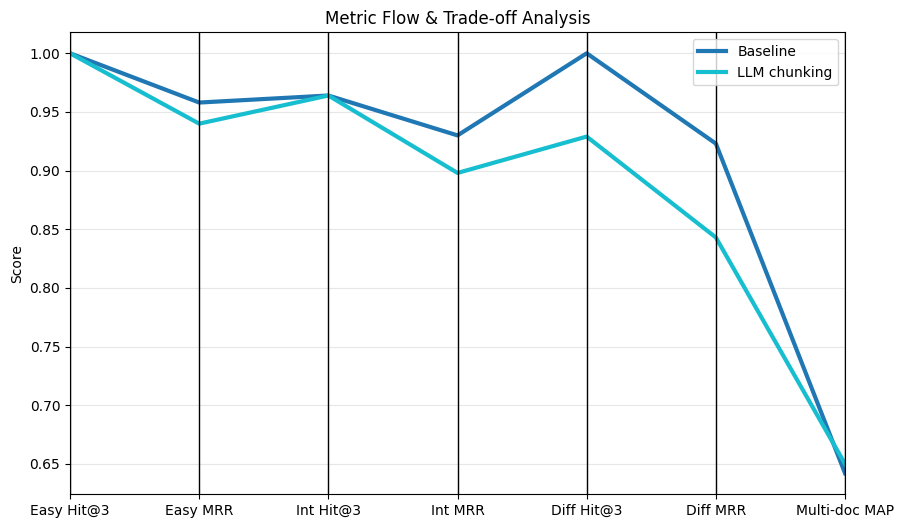

In [26]:
def plot_parallel_matplotlib(df):
    metrics = [col for col in df.columns if "MRR" in col or "Hit@3" in col or "MAP" in col]
    plot_df = df[['Method'] + metrics]

    plt.figure(figsize=(10, 6))
    parallel_coordinates(plot_df, 'Method', colormap='tab10', axvlines=True, linewidth=3)
    
    plt.title("Metric Flow & Trade-off Analysis")
    plt.ylabel("Score")
    plt.grid(alpha=0.3)
    plt.show()

plot_parallel_matplotlib(final_results)

This plot shows that naive chunking slightly outperforms LLM chunking on recall-focused metrics like MRR, especiallly for more difficult queries. This is expected, as smaller chunks (baseline) tend to achieve higher cosine similarity scores with short queries. 

However, the overall performance gap is small, and both approaches behave very similarly on easy and intermediate queries. Importantly, multi-document MAP is almost identical, suggesting that LLM chunking preserves overall document relevance while producing fewer, more structured chunks. This highlights a clear trade-off: naive chunking favors recall, while LLM chunking offers better structure without a major loss in retrieval quality.

In [27]:
def run_retrievals_once(retrievers, queries, max_k=10):
    """
    Runs retrieval ONCE and stores ranked document lists.
    """
    #alpha_by_retriever = {"Dual": best_alpha}
    retrieval_cache = {}
    for name, retriever in retrievers.items():
        #alpha = alpha_by_retriever.get(name, 0.5) if alpha_by_retriever else 0.5
        retrieval_cache[name] = {}

        for query in queries:
            ranked_docs = ranked_docs_from_retriever(retriever, query, max_k=max_k)
            retrieval_cache[name][query] = ranked_docs

    return retrieval_cache


def visualize_trap_results(retrieval_cache, trap_queries, max_k=10):
    """
    Heatmap of trap-query ranks.
    """
    rows = []

    for retriever_name, queries in retrieval_cache.items():
        for query, target_doc in trap_queries.items():
            ranked_docs = queries.get(query, [])

            rank = None
            for i, doc in enumerate(ranked_docs, start=1):
                if doc == target_doc:
                    rank = i
                    break

            rows.append({"Retriever": retriever_name,"Trap Query": query[:45] + "...","Rank": rank})

    df = pd.DataFrame(rows)
    pivot_values = df.pivot(index="Trap Query", columns="Retriever", values="Rank")
    pivot_labels = pivot_values.applymap(lambda x: "Not Found" if pd.isna(x) else str(int(x)))
    plot_data = pivot_values.fillna(max_k + 1)

    plt.figure(figsize=(12, 8))
    sns.heatmap(plot_data, annot=pivot_labels, fmt="", cmap="RdYlGn_r", vmin=1, vmax=max_k, cbar_kws={"label": "Rank (1 = best)"})
    plt.title("Adversarial Trap Analysis: Attribution & Robustness")
    plt.tight_layout()
    plt.show()


C:\Users\lucia\AppData\Local\Temp\ipykernel_5752\3843615060.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_labels = pivot_values.applymap(lambda x: "Not Found" if pd.isna(x) else str(int(x)))


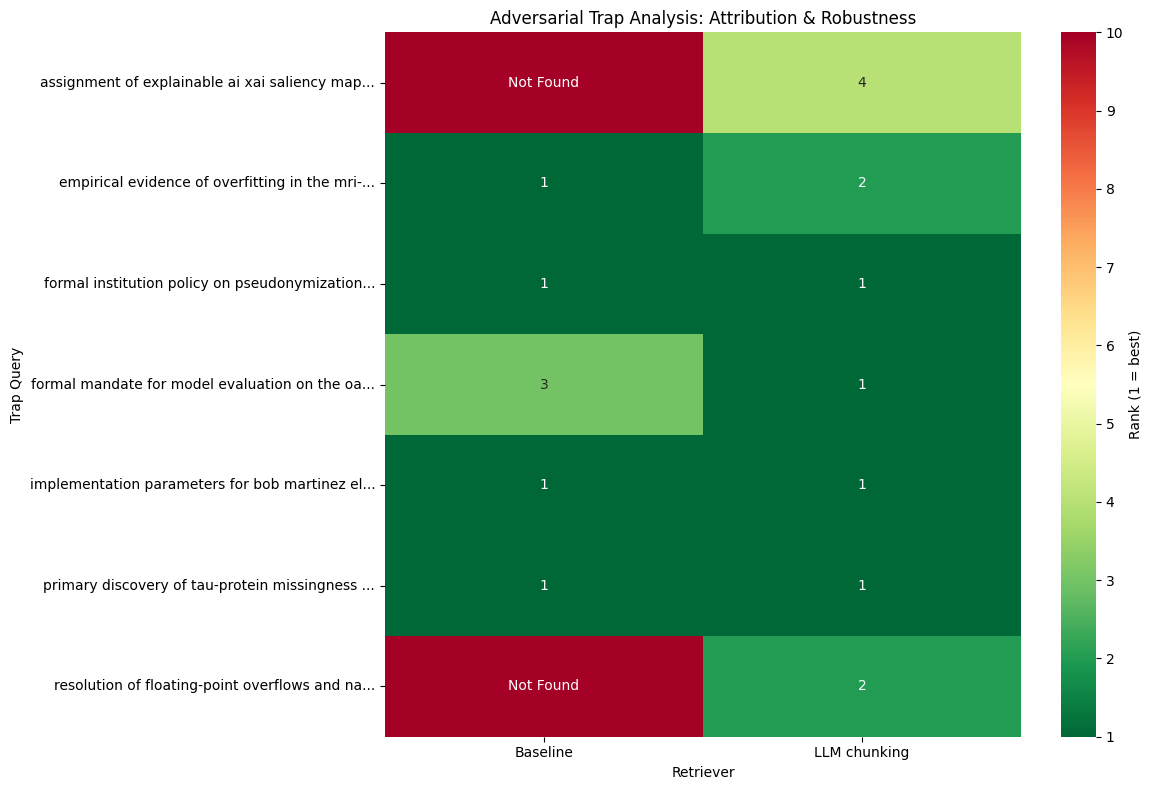

In [28]:
retrieval_traps = run_retrievals_once(
    retrievers,
    queries_traps)

visualize_trap_results(retrieval_traps, queries_traps)

This plot shows that LLM-based chunking is more robust for trap queries that require understanding who did what and why, rather than just matching keywords. In queries like the saliency assignment and numerical instability traps, the baseline fails to retrieve any relevant document, while LLM chunking still finds the correct source within the top ranks.

For more straightforward cases, such as clear discoveries or implementation details, both approaches perform similarly. 

Overall, while naive chunking benefits from smaller chunks and works well for simple matching, LLM chunking handles adversarial and intent-based queries better, as it preserves more context and reduces brittle, keyword-driven failures.

For this reason, and the fact that the multi-document MAP score is very similar in both cases, we have decided to use llm chunking for the next experiments. 

## OTHER

In [29]:
def hit_at_k_vs_threshold(retrieval_cache, evaluation_pairs, thresholds, k=3):
    hits_by_retriever = {}

    for name, results_by_query in retrieval_cache.items():
        hits_by_retriever[name] = []

        for t in thresholds:
            hits = 0
            for query, expected_pdf in evaluation_pairs.items():
                results = [
                    r for r in results_by_query[query]
                    if r["score"] >= t
                ]

                for r in results[:k]:
                    if r["pdf_name"] == expected_pdf:
                        hits += 1
                        break

            hits_by_retriever[name].append(hits)

    return hits_by_retriever


In [30]:
thresholds = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]

hits_by_retriever = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

plt.figure()
for name, hits in hits_by_retriever.items():
    plt.plot(thresholds, hits, label=name)

plt.xlabel("Similarity threshold")
plt.ylabel("Number of correct retrieves (Hit@3)")
plt.title("Hit@3 vs Similarity Threshold")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'retrieval_easy' is not defined

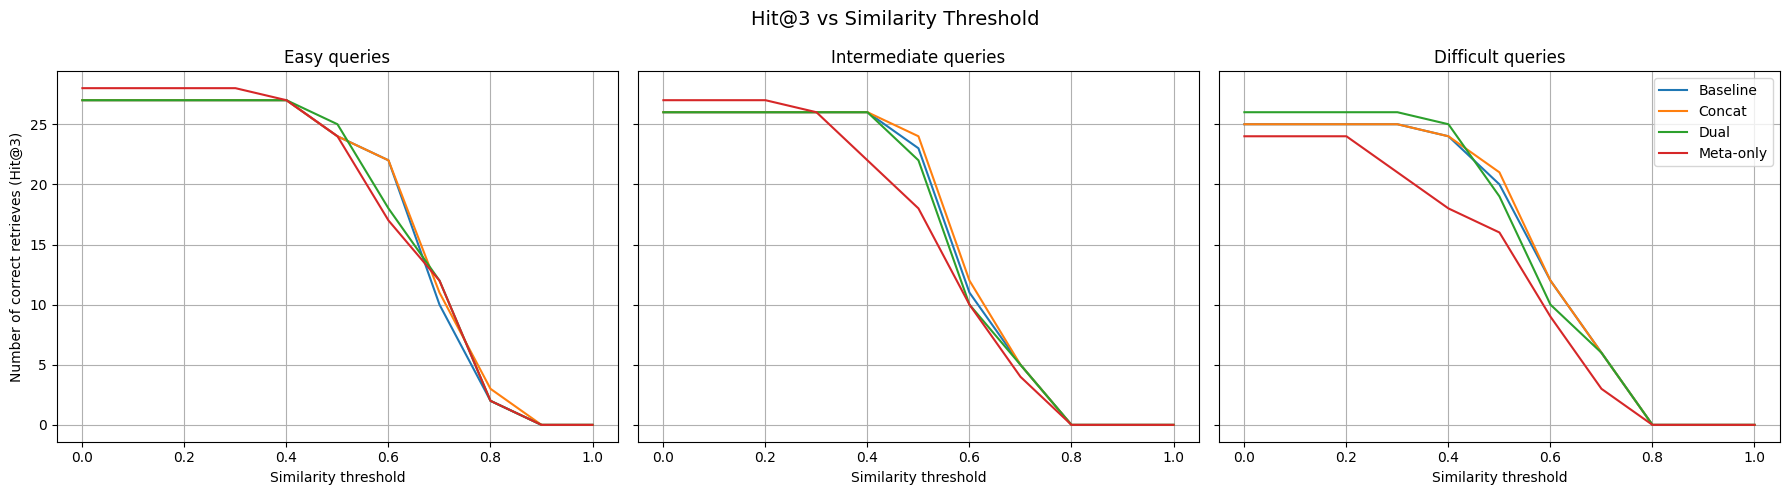

In [16]:
hits_by_retriever_easy = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

hits_by_retriever_intermediate = hit_at_k_vs_threshold(
    retrieval_intermediate,
    queries_intermediate,
    thresholds,
    k=3)

hits_by_retriever_difficult = hit_at_k_vs_threshold(
    retrieval_difficult,
    queries_difficult,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plots = [
    ("Easy queries", hits_by_retriever_easy),
    ("Intermediate queries", hits_by_retriever_intermediate),
    ("Difficult queries", hits_by_retriever_difficult),
]

for ax, (title, hits_dict) in zip(axes, plots):
    for name, hits in hits_dict.items():
        ax.plot(thresholds, hits, label=name)

    ax.set_title(title)
    ax.set_xlabel("Similarity threshold")
    ax.grid(True)

axes[0].set_ylabel("Number of correct retrieves (Hit@3)")

# Llegendària comuna
axes[-1].legend(loc="best")

plt.suptitle("Hit@3 vs Similarity Threshold", fontsize=14)
plt.tight_layout()
plt.show()